# VolEdge — Analysis Notebook

This notebook produces the two headline results referenced in the README:

1. **Implied volatility smile** — back out IV from an options chain and
   show the characteristic smile/skew shape.
2. **Delta-hedging error vs. rebalancing frequency** — quantify how
   discretization error in dynamic hedging shrinks as you rebalance
   more often.

It also sanity-checks the three pricers (Black-Scholes, binomial tree,
Monte Carlo) against each other before using them for anything else.

**Note on data**: this notebook uses a synthetic options chain (constructed
from a parametric vol-skew function) rather than a live pull, so the plots
below are reproducible offline and don't depend on market hours or a
network connection. The live version — pulling a real chain via
`yfinance` and running the same IV solver on it — is what `streamlit_app.py`
does; run that for live data. See README "Limitations" for why this
distinction matters.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt

from src.pricing.black_scholes import bs_call, bs_put, OptionType
from src.pricing.binomial_tree import binomial_price
from src.pricing.monte_carlo import mc_price
from src.implied_vol import implied_volatility
from src.hedging import hedging_error_vs_frequency

plt.style.use("seaborn-v0_8-whitegrid")

## 1. Pricer cross-check

All three pricers should agree closely for a plain-vanilla European call.

In [2]:
S, K, T, r, sigma = 100.0, 100.0, 1.0, 0.05, 0.20

bs = bs_call(S, K, T, r, sigma)
tree = binomial_price(S, K, T, r, sigma, n_steps=500, option_type=OptionType.CALL)
mc = mc_price(S, K, T, r, sigma, n_paths=200_000, seed=42)

print(f"Black-Scholes:  {bs:.4f}")
print(f"Binomial tree:  {tree:.4f}  (diff: {abs(tree - bs):.5f})")
print(f"Monte Carlo:    {mc.price:.4f} +/- {1.96*mc.std_error:.4f} (95% CI)")

Black-Scholes:  10.4506
Binomial tree:  10.4466  (diff: 0.00400)
Monte Carlo:    10.4763 +/- 0.0649 (95% CI)


## 2. Binomial tree convergence to Black-Scholes

As the number of steps grows, the CRR tree price should converge to the
closed-form Black-Scholes price. This is the core numerical-correctness
check for the tree pricer (also enforced in `tests/test_pricing.py`).

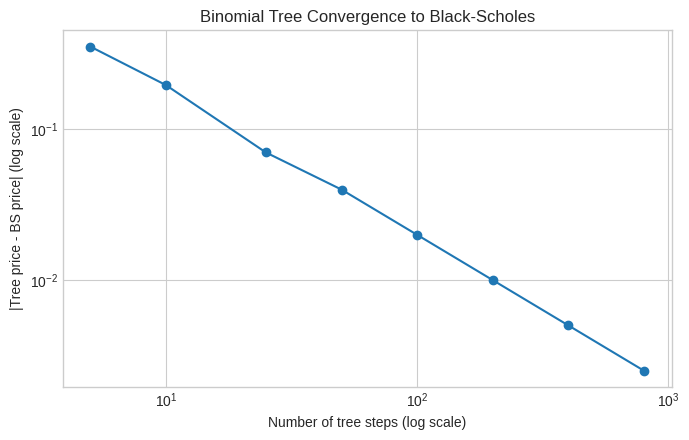

In [3]:
step_counts = [5, 10, 25, 50, 100, 200, 400, 800]
errors = [abs(binomial_price(S, K, T, r, sigma, n_steps=n) - bs) for n in step_counts]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(step_counts, errors, marker="o")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Number of tree steps (log scale)")
ax.set_ylabel("|Tree price - BS price| (log scale)")
ax.set_title("Binomial Tree Convergence to Black-Scholes")
fig.tight_layout()
fig.savefig("../assets/convergence.png", dpi=150)
plt.show()

## 3. Implied volatility smile

Construct a synthetic options chain with a realistic skew (OTM puts /
ITM calls priced with higher implied vol than ATM, matching the typical
equity index skew shape), then run the IV solver strike-by-strike to
recover the smile.

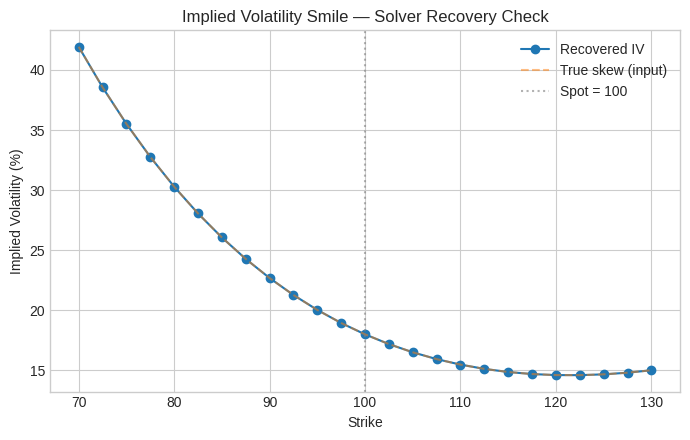

Recovered 25/25 strikes.
Max abs error vs. true input vol: 0.000002


In [4]:
spot = 100.0
expiry_T = 0.25
risk_free = 0.045
strikes = np.arange(70, 131, 2.5)


def synthetic_skew(strike: float, spot: float) -> float:
    """A simple parametric skew: higher IV for OTM puts (low strikes),
    a smile-shaped bump for both tails, roughly matching equity-index
    skew shape. Purely illustrative, not fit to any real market."""
    moneyness = np.log(strike / spot)
    atm_vol = 0.18
    skew_slope = -0.35     # negative slope: downside strikes trade richer
    smile_curvature = 0.9  # convexity, tails higher than ATM
    return atm_vol + skew_slope * moneyness + smile_curvature * moneyness**2


true_vols = [synthetic_skew(k, spot) for k in strikes]
synthetic_prices = [
    bs_call(spot, k, expiry_T, risk_free, v) if k >= spot else bs_put(spot, k, expiry_T, risk_free, v)
    for k, v in zip(strikes, true_vols)
]

recovered_strikes, recovered_ivs = [], []
for k, price in zip(strikes, synthetic_prices):
    opt_type = OptionType.CALL if k >= spot else OptionType.PUT
    result = implied_volatility(price, spot, k, expiry_T, risk_free, opt_type)
    if result.converged:
        recovered_strikes.append(k)
        recovered_ivs.append(result.iv)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(recovered_strikes, [v * 100 for v in recovered_ivs], marker="o", label="Recovered IV")
ax.plot(strikes, [v * 100 for v in true_vols], "--", alpha=0.5, label="True skew (input)")
ax.axvline(spot, color="gray", linestyle=":", alpha=0.6, label=f"Spot = {spot:.0f}")
ax.set_xlabel("Strike")
ax.set_ylabel("Implied Volatility (%)")
ax.set_title("Implied Volatility Smile — Solver Recovery Check")
ax.legend()
fig.tight_layout()
fig.savefig("../assets/vol_smile.png", dpi=150)
plt.show()

print(f"Recovered {len(recovered_strikes)}/{len(strikes)} strikes.")
max_err = max(abs(a - b) for a, b in zip(recovered_ivs, true_vols[: len(recovered_ivs)]))
print(f"Max abs error vs. true input vol: {max_err:.6f}")

## 4. Delta-hedging error vs. rebalancing frequency

Sell an ATM call, delta-hedge it dynamically under GBM, and measure the
standard deviation of hedging P&L at expiry across simulated paths, for
a range of rebalancing frequencies. Theory says this should shrink
monotonically as rebalancing gets more frequent (residual error from
discrete- vs. continuous-time hedging).

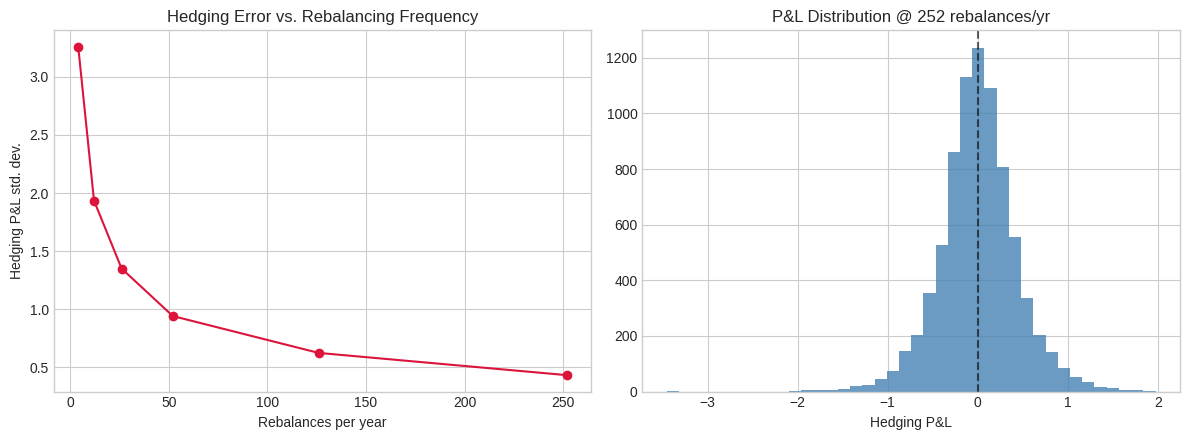

rebalances/yr=   4   std=3.2599   mean=-0.0480
rebalances/yr=  12   std=1.9353   mean=-0.0390
rebalances/yr=  26   std=1.3500   mean=-0.0183
rebalances/yr=  52   std=0.9408   mean=-0.0012
rebalances/yr= 126   std=0.6234   mean=-0.0027
rebalances/yr= 252   std=0.4318   mean=+0.0060


In [5]:
rebalance_freqs = [4, 12, 26, 52, 126, 252]
hedge_results = hedging_error_vs_frequency(
    S0=100, K=100, T=1.0, r=0.05, sigma=0.20,
    rebalance_counts=rebalance_freqs,
    option_type=OptionType.CALL,
    n_paths=8000,
    seed=42,
)

freqs = sorted(hedge_results.keys())
stds = [hedge_results[f].std for f in freqs]
means = [hedge_results[f].mean for f in freqs]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.plot(freqs, stds, marker="o", color="crimson")
ax1.set_xlabel("Rebalances per year")
ax1.set_ylabel("Hedging P&L std. dev.")
ax1.set_title("Hedging Error vs. Rebalancing Frequency")

ax2.hist(hedge_results[freqs[-1]].pnl, bins=40, color="steelblue", alpha=0.8)
ax2.axvline(0, color="black", linestyle="--", alpha=0.6)
ax2.set_xlabel("Hedging P&L")
ax2.set_title(f"P&L Distribution @ {freqs[-1]} rebalances/yr")

fig.tight_layout()
fig.savefig("../assets/hedging_error.png", dpi=150)
plt.show()

for f, s, m in zip(freqs, stds, means):
    print(f"rebalances/yr={f:4d}   std={s:.4f}   mean={m:+.4f}")

## 5. Heston stochastic volatility: calibrating to the smile

Every pricer used so far assumes a single constant volatility - the
smile in section 3 is direct proof that assumption is wrong (if it were
right, every strike would back out the same sigma). Heston lets
variance itself be a mean-reverting stochastic process correlated with
the asset's returns, and can be calibrated directly to a set of market
option prices rather than to the IVs derived from them.

We calibrate to the same synthetic skew from section 3 (converting the
put prices for K < spot into call-equivalent prices via put-call parity
first, so the whole calibration set is on a consistent single-type
basis).

In [6]:
from src.pricing.heston import calibrate_heston, heston_price
import math

call_equiv_prices = []
for k, price, opt_type in zip(strikes, synthetic_prices, [
    OptionType.CALL if k >= spot else OptionType.PUT for k in strikes
]):
    if opt_type == OptionType.PUT:
        # Put-call parity: C = P + S*e^{-qT} - K*e^{-rT}
        call_equiv_prices.append(price + spot - k * math.exp(-risk_free * expiry_T))
    else:
        call_equiv_prices.append(price)
call_equiv_prices = np.array(call_equiv_prices)

calibrated_params, calib_rmse = calibrate_heston(
    S=spot, T=expiry_T, r=risk_free,
    strikes=strikes, market_prices=call_equiv_prices,
    option_type=OptionType.CALL,
)

print("Calibrated Heston parameters:")
print(f"  v0      = {calibrated_params.v0:.4f}  (initial variance, sqrt = {math.sqrt(calibrated_params.v0)*100:.1f}% vol)")
print(f"  kappa   = {calibrated_params.kappa:.4f}  (mean-reversion speed)")
print(f"  theta   = {calibrated_params.theta:.4f}  (long-run variance, sqrt = {math.sqrt(calibrated_params.theta)*100:.1f}% vol)")
print(f"  sigma_v = {calibrated_params.sigma_v:.4f}  (vol of vol)")
print(f"  rho     = {calibrated_params.rho:.4f}  (spot-vol correlation)")
print(f"\nCalibration RMSE (price units): {calib_rmse:.4f}")

Calibrated Heston parameters:
  v0      = 0.0057  (initial variance, sqrt = 7.6% vol)
  kappa   = 19.9986  (mean-reversion speed)
  theta   = 0.0431  (long-run variance, sqrt = 20.7% vol)
  sigma_v = 1.4297  (vol of vol)
  rho     = -0.6120  (spot-vol correlation)

Calibration RMSE (price units): 0.1228


### Heston-implied smile vs. the target smile

Convert the calibrated Heston model's own prices back to Black-Scholes
IV (the same solver from section 3) to compare its implied smile shape
directly against the target.

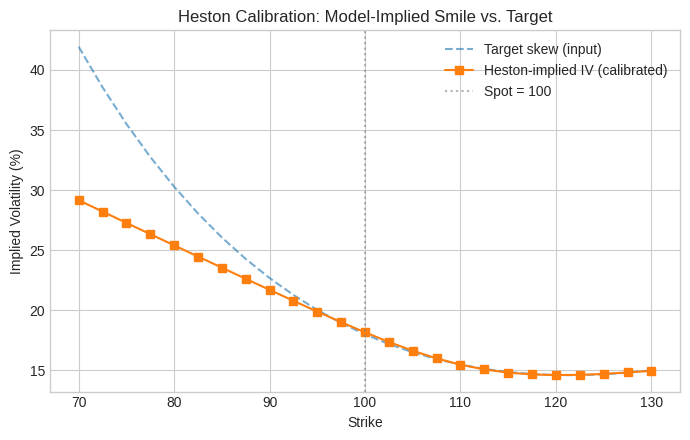

In [7]:
heston_prices = np.array(
    [heston_price(spot, k, expiry_T, risk_free, calibrated_params, OptionType.CALL) for k in strikes]
)

heston_ivs = []
for k, p in zip(strikes, heston_prices):
    result = implied_volatility(p, spot, k, expiry_T, risk_free, OptionType.CALL)
    heston_ivs.append(result.iv if result.converged else np.nan)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(strikes, [v * 100 for v in true_vols], "--", alpha=0.6, label="Target skew (input)")
ax.plot(strikes, [v * 100 for v in heston_ivs], marker="s", label="Heston-implied IV (calibrated)")
ax.axvline(spot, color="gray", linestyle=":", alpha=0.6, label=f"Spot = {spot:.0f}")
ax.set_xlabel("Strike")
ax.set_ylabel("Implied Volatility (%)")
ax.set_title("Heston Calibration: Model-Implied Smile vs. Target")
ax.legend()
fig.tight_layout()
fig.savefig("../assets/heston_calibration.png", dpi=150)
plt.show()

Heston has 5 free parameters and cannot fit an arbitrary smile shape
exactly - it's a specific stochastic process, not a spline through the
data. The fit above is close but not exact, and that gap is itself
informative: it shows where this particular quadratic target skew
isn't representable by Heston's functional form (see README
Limitations for more on this).

## 6. Risk: VaR and scenario stress testing

Two different questions about risk, both worth asking separately:

- **VaR**: at a given confidence level, what's the loss threshold over
  a short horizon? Computed two ways - delta-normal (fast, linear) and
  Monte Carlo full revaluation (slower, captures gamma) - and compared
  directly, the way a risk desk would cross-check one against the
  other rather than trusting either alone.
- **Stress test**: under a *named* scenario (spot down 20%, vol up 10
  points), what's the P&L? This doesn't depend on any assumption about
  how likely the scenario is - it's a direct "what if" question.

In [8]:
from src.risk import parametric_var, monte_carlo_var, stress_test

position_S, position_K, position_T, position_r, position_sigma = 100.0, 100.0, 0.5, 0.05, 0.22

pvar = parametric_var(
    position_S, position_K, position_T, position_r, position_sigma,
    OptionType.CALL, position_size=100, horizon_days=1, confidence=0.95,
)
mvar = monte_carlo_var(
    position_S, position_K, position_T, position_r, position_sigma,
    OptionType.CALL, position_size=100, horizon_days=1, confidence=0.95, seed=42,
)

print("1-day 95% VaR for a long 100-contract call position:")
print(f"  Parametric (delta-normal): VaR = {pvar.var:8.2f}   CVaR = {pvar.cvar:8.2f}")
print(f"  Monte Carlo (full reval):  VaR = {mvar.var:8.2f}   CVaR = {mvar.cvar:8.2f}")
print(f"  Relative difference: {abs(pvar.var - mvar.var) / mvar.var:.1%}")

1-day 95% VaR for a long 100-contract call position:
  Parametric (delta-normal): VaR =   112.56   CVaR =   141.15
  Monte Carlo (full reval):  VaR =   109.24   CVaR =   134.40
  Relative difference: 3.0%


### Scenario stress test

P&L grid for a long 100-contract call, by spot/vol shock:

           vol -10%  vol -5%  vol +0%  vol +5%  vol +10%
spot -20%   -741.18  -721.68  -677.65  -613.37   -534.63
spot -10%   -670.51  -574.15  -463.19  -345.09   -223.13
spot -5%    -528.92  -397.85  -264.89  -131.19      2.76
spot +0%    -271.58  -136.66     0.00   137.32    274.86
spot +5%      94.34   203.65   326.78   456.53    589.82
spot +10%    534.21   606.70   705.83   819.95    942.85
spot +20%   1505.44  1525.61  1574.54  1648.54   1740.92


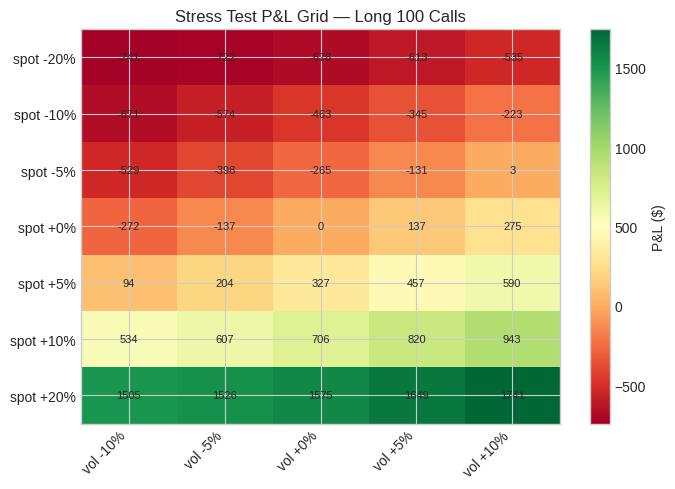

In [9]:
stress_table = stress_test(
    position_S, position_K, position_T, position_r, position_sigma,
    OptionType.CALL, position_size=100,
)
print("P&L grid for a long 100-contract call, by spot/vol shock:\n")
print(stress_table.round(2))

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(stress_table.values, cmap="RdYlGn", aspect="auto")
ax.set_xticks(range(len(stress_table.columns)))
ax.set_xticklabels(stress_table.columns, rotation=45, ha="right")
ax.set_yticks(range(len(stress_table.index)))
ax.set_yticklabels(stress_table.index)
ax.set_title("Stress Test P&L Grid — Long 100 Calls")
for i in range(len(stress_table.index)):
    for j in range(len(stress_table.columns)):
        ax.text(j, i, f"{stress_table.values[i,j]:.0f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, label="P&L ($)")
fig.tight_layout()
fig.savefig("../assets/stress_test.png", dpi=150)
plt.show()

## Takeaways

- The binomial tree converges to Black-Scholes at the expected rate as
  step count increases, and Monte Carlo brackets the closed-form price
  within its confidence interval — cross-validating all three pricers.
- The IV solver recovers an input skew to within a small tolerance
  across strikes, including the low-vega tails where Newton-Raphson
  alone would fail (handled by the Brent fallback in `implied_vol.py`).
- Hedging error (P&L std. dev.) falls monotonically as rebalancing
  frequency increases, consistent with discrete-hedging theory. Mean
  P&L stays near zero throughout — the simulation is a variance story,
  not a directional edge, exactly as it should be under a correctly
  specified model.
- Heston, calibrated to the same target skew, recovers a similarly
  shaped smile without being told the functional form in advance - it's
  an approximation, not an exact fit, and the gap between the two
  curves is itself informative about the model's limits.
- Parametric and Monte Carlo VaR agree closely at a 1-day horizon
  (small convexity effects), and the stress test grid shows the
  expected signs throughout: a long call gains from both a spot rally
  and a vol increase, and loses from the reverse.